In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [5]:
#Equations

def dX(X, Y, sigma = 10): 
    """
    Computes the value of the function dx = - sigma(X - Y)
    
    Parameters
    ----------
    X : float or int
        Input value proporitonal to the intensity of the convective motion.
    Y : float or int
        Input value proportional to the temperature difference of ascending and descending currents.
    sigma : int
            Ratio of the kinematic viscosity to the thermal diffusivity. 
        
    Returns
    ----------
    float 
        The value of the function at X and Y.
    
    """
    
    return - sigma * (X - Y)


def dY(X, Y, Z, r = 28):
    """
    Computes the value of the function dY = rX - Y - XZ
    
    Parameters
    ----------
    X : float or int
        Input value proporitonal to the intensity of the convective motion.
    Y : float or int
        Input value proportional to the temperature difference of ascending and descending currents.
    Z : float or int
        Input value proportional to the distortion of the vertical temperature profile from linearity. 
    r : int
        Rayleigh number. 
        
    Returns
    ----------
    float 
        The value of the function at X, Y and Z.
    """
    
    return (r * X) - Y - (X * Z)

def dZ(X, Y, Z, b = 8 / 3):
    """
    Computes the value of the function dZ = -bZ + XY.
    
    Parameters
    ----------
    X : float or int
        Input value proporitonal to the intensity of the convective motion.
    Y : float or int
        Input value proportional to the temperature difference of ascending and descending currents.
    Z : float or int
        Input value proportional to the distortion of the vertical temperature profile from linearity. 
    b : int
        dimensionless length scale. 
        
    Returns
    ----------
    float 
        The value of the function at X, Y and Z.
    """
        
    return - b * Z + X * Y

#Lorenz funciton

def lorenz(t, a):
    """
    Computes each of the Lorenz equations over a given time.
    
    Parameters
    ----------
    t : int or float
        Input value, dimensionless time. 
    a : array-like of length 3
        Sate vector:
        a[0] = X 
        a[1] = Y
        a[2] = Z
        
    Returns
    ----------
    list
        A list containg the derivatives [dX/dt, dY/dt, dZ/dt]. 
    """
    X, Y, Z = a
    
    dXdt = dX(X, Y)
    dYdt = dY(X, Y, Z)
    dZdt = dZ(X, Y, Z)
    
    return [dXdt, dYdt, dZdt]


In [6]:
#Time span

span = (0, 60)

#Initial conditions 

a_0 = [0, 1, 0]

#Integration 

points = np.linspace(0, 60, 3000)

sol = solve_ivp(lorenz, span, a_0, t_eval = points, max_step = 0.02)

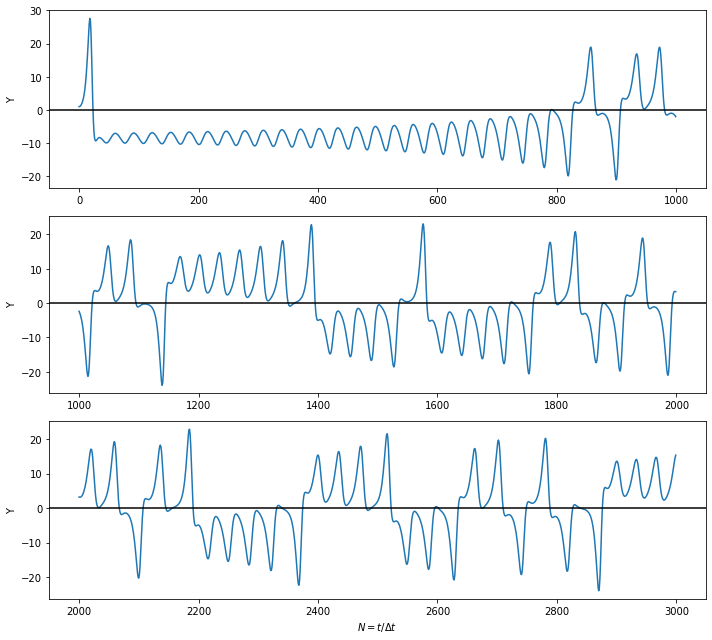

In [12]:
#Plot 

fig, ax = plt.subplots(3, 1, figsize=(10, 9))

ax[0].plot(np.arange(0, 1000), sol.y[1][:1000])
ax[0].set_ylabel('Y')
ax[0].axhline(0, linestyle = '-', color = 'black')

ax[1].plot(np.arange(1000, 2000), sol.y[1][1000:2000])
ax[1].set_ylabel('Y')
ax[1].axhline(0, linestyle = '-', color = 'black')

ax[2].plot(np.arange(2000,3000), sol.y[1][2000:3000])
ax[2].set_ylabel('Y')
ax[2].set_xlabel('$N=t/\Delta t$')
ax[2].axhline(0, linestyle = '-', color = 'black')

plt.tight_layout()
plt.savefig('Lorenz_fig_1.png')
plt.show()

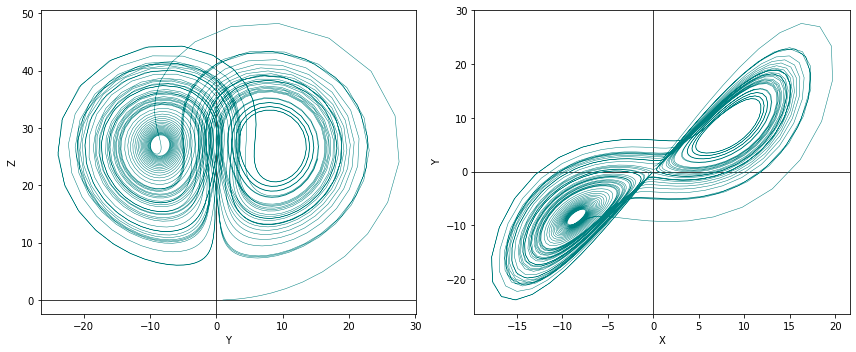

In [13]:
#Plot 

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].axhline(0, linestyle = '-', color = 'black', lw = 0.75)
ax[0].axvline(0, linestyle = '-', color = 'black', lw = 0.75)
ax[0].plot(sol.y[1], sol.y[2], lw = 0.5, color = 'teal')
ax[0].set_ylabel('Z')
ax[0].set_xlabel('Y')

ax[1].axhline(0, linestyle = '-', color = 'black', lw = 0.75)
ax[1].axvline(0, linestyle = '-', color = 'black', lw = 0.75)
ax[1].plot(sol.y[0], sol.y[1], lw = 0.5, color = 'teal')
ax[1].set_ylabel('Y')
ax[1].set_xlabel('X')

plt.tight_layout()
plt.savefig('Lorenz_fig_2.png')
plt.show()

In [ ]:
#second solution

a_2 = np.array(a_0) + 1e-8

sol_2 = solve_ivp(lorenz, span, a_2, t_eval = points, max_step = 0.02)

#Distance between solutions 

diff_sol = np.linalg.norm(sol.y - sol_2.y, axis = 0)

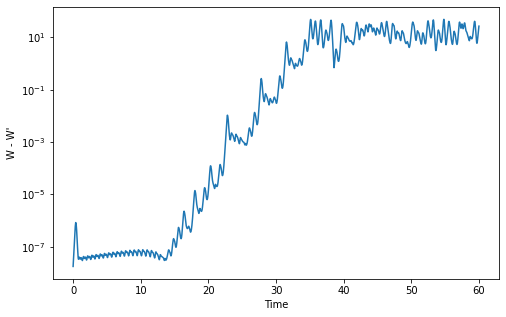

In [16]:
#Plot

plt.figure(figsize = (8,5))
plt.semilogy(sol.t, diff_sol)
plt.xlabel('Time')
plt.ylabel("W - W'")
plt.savefig('Lorenz_dist.png')
plt.show()